# Open Field Test — NWB Data Access Demo

**Dataset:** Meletis Lab, Karolinska Institutet  
**Publication:** [Mantas et al. (2024) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)

This notebook demonstrates two example sessions from the Open Field Test (OFT) dataset:

- **Example 1 — VAME behavioral motifs:** An Anxa1-Flp mouse (Tetanus toxin model) with pose
  estimation and both VAME motif labellings (157-dim and 36-dim models, 47 k-means clusters each).
- **Example 2 — Fiber photometry + kinematics:** An Anxa1-Flp mouse from the `oft_fp`
  sub-experiment with simultaneous jGCaMP8m fiber photometry (dCP) and derived kinematics.

## About the experiment

Mice explored a 40×40 cm arena with a transparent floor, recorded from below at 30 fps.
The OFT was used to study locomotion and behavioral motifs in mouse models of Parkinson's disease.
Seven sub-experiments were conducted across multiple dopamine-related genetic and lesion models
(6-OHDA, Anxa1-TetTox, MitoPark, anti-Anxa1 antibody).

## Data streams per NWB file

| Stream | NWB location | Rate | Description |
|--------|-------------|------|-------------|
| **Video** | `acquisition/Video {name}` | 30 fps | External reference to MP4 file (not embedded) |
| **Pose estimation** | `processing/behavior/PoseEstimationDeepLabCut` | 30 Hz | DeepLabCut output — 6 keypoints (x, y, confidence) |
| **VAME motifs** | `processing/behavior/VAMEProject{157,36}` | 30 Hz | `VAMEProject` container holding a `MotifSeries` of integer k-means labels per frame |
| **Fiber photometry** | `processing/ophys/DfOverFFiberPhotometryResponseSeries` | ~60 Hz | Processed dF/F signal (470 nm signal minus 405 nm isosbestic reference) |
| **Kinematics** | `processing/behavior/Kinematics` | 30 Hz | Derived speed, acceleration, angular speed, distance metrics |

Not all streams are present in every session. Fiber photometry is only available in the
`oft_fp` sub-experiment (31 of 161 sessions). VAME motifs are available for most sessions.
The directory names `vame_157` / `vame_36` refer to the VAME latent-space dimension used during
training; both models use **47 k-means clusters** (labels 0–46).

## Setup

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Example 1: Behavioral motifs session

This session (sub-687643, Anxa1-Flp, Tetanus toxin / TetTox model) contains video,
pose estimation, and both VAME motif labellings (157-dim and 36-dim models).

In [50]:
nwb_path_vame = "../../../nwb_output/open_field_test/sub-687643/sub-687643_ses-oft-2023-05-16T15-31-06.nwb"

io1 = NWBHDF5IO(nwb_path_vame, mode="r")
nwbfile1 = io1.read()

print(f"Session ID:    {nwbfile1.session_id}")
print(f"Session start: {nwbfile1.session_start_time}")
print(f"Subject ID:    {nwbfile1.subject.subject_id}")
print(f"Genotype:      {nwbfile1.subject.genotype}")
print(f"Sex:           {nwbfile1.subject.sex}")
print(f"Institution:   {nwbfile1.institution}")
print(f"Lab:           {nwbfile1.lab}")

Session ID:    oft-2023-05-16T15-31-06
Session start: 2023-05-16 15:31:06+02:00
Subject ID:    687643
Genotype:      anxa1-flp
Sex:           M
Institution:   Karolinska Institutet
Lab:           Meletis


### 1.1 Video (external reference)

Videos are stored as external file references rather than embedded pixel data.
Each session has one MP4 video (H.264, 30 fps, ~856×818 pixels) recorded from below
through a transparent floor.

In [51]:
video_key = next(k for k in nwbfile1.acquisition if k.startswith("Video"))
video = nwbfile1.acquisition[video_key]
print(f"Video name:    {video.name}")
print(f"External file: {video.external_file[0]}")
print(f"Starting time: {video.starting_time} s")
print(f"Rate:          {video.rate} fps")

Video name:    Video oft_2023-05-16T15_31_06
External file: /Volumes/T9/data/Meletis/oft/videos/oft_2023-05-16T15_31_06.mp4
Starting time: 0.0 s
Rate:          30.0 fps


### 1.2 Pose estimation (DeepLabCut)

Pose estimation was performed using DeepLabCut, tracking 6 keypoints on each mouse:
**snout**, **left front paw**, **right front paw**, **left back paw**, **right back paw**,
and **tail base**. Stored via the [ndx-pose](https://github.com/rly/ndx-pose) extension.

Each keypoint has:
- `data` — (N, 2) array of (x, y) pixel coordinates at 30 Hz
- `confidence` — (N,) array of DLC likelihood scores per frame

In [52]:
behavior1 = nwbfile1.processing["behavior"]
pose = behavior1["PoseEstimationDeepLabCut"]

keypoint_names = [k.replace("PoseEstimationSeries", "") for k in pose.pose_estimation_series]
print(f"Keypoints ({len(keypoint_names)}): {keypoint_names}")
print(f"Scorer: {pose.scorer}")
print(f"Source software: {pose.source_software}")

snout = pose.pose_estimation_series["PoseEstimationSeriesSnout"]
print(f"\nSnout data shape: {snout.data.shape}  (frames × [x, y])")
print(f"Confidence shape: {snout.confidence.shape}")
print(f"Number of frames: {snout.data.shape[0]}")

Keypoints (6): ['Leftbackpaw', 'Leftfrontpaw', 'Rightbackpaw', 'Rightfrontpaw', 'Snout', 'Tailbase']
Scorer: DLC_resnet50_oft_roomIVASep13shuffle1_950000
Source software: DeepLabCut

Snout data shape: (9000, 2)  (frames × [x, y])
Confidence shape: (9000,)
Number of frames: 9000


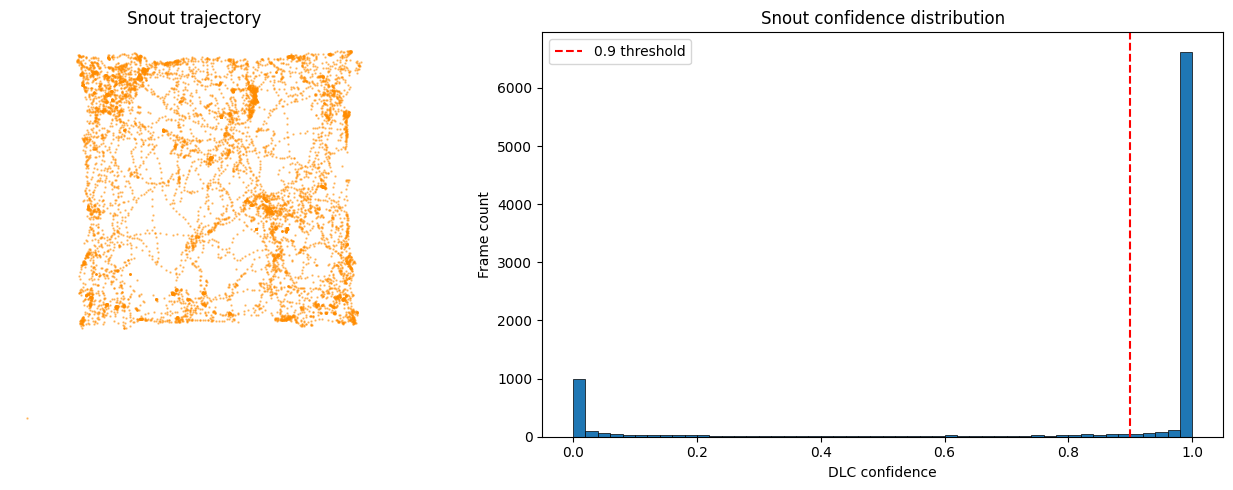

In [60]:
snout_xy = snout.data[:]
confidence = snout.confidence[:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
time_s = np.arange(len(snout_xy)) / 30.0
sc = ax.scatter(snout_xy[:, 0], snout_xy[:, 1], c="darkorange", s=0.5,alpha=0.5)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Snout trajectory")
ax.set_aspect("equal")
ax.axis("off")
#plt.colorbar(sc, ax=ax, label="Time (s)")

ax = axes[1]
ax.hist(confidence, bins=50, edgecolor="black", linewidth=0.5)
ax.set_xlabel("DLC confidence")
ax.set_ylabel("Frame count")
ax.set_title("Snout confidence distribution")
ax.axvline(0.9, color="red", linestyle="--", label="0.9 threshold")
ax.legend()

plt.tight_layout()
plt.show()

### 1.3 VAME behavioral motifs

[VAME](https://github.com/EthoML/VAME) (Variational Animal Motion Embedding) was applied for
unsupervised behavioral classification. Each frame is assigned an integer motif label via k-means
clustering of the VAME latent space. Two VAME models were applied:

- **157-dim model** (`VAMEProject157`) — latent dimension 157, 47 k-means clusters
- **36-dim model** (`VAMEProject36`) — latent dimension 36, 47 k-means clusters

Both are stored in `processing/behavior/`. Access labels via `project.motif_series.data[:]`.

VAMEProject157:
  MotifSeries name:       VAMEMotifs157
  Shape:                  (8970,)  (299.0 s at 30.0 Hz)
  Unique motifs:          44  (labels 0–46)
  Pose estimation linked: True

VAMEProject36:
  MotifSeries name:       VAMEMotifs36
  Shape:                  (8970,)  (299.0 s at 30.0 Hz)
  Unique motifs:          43  (labels 0–46)
  Pose estimation linked: True



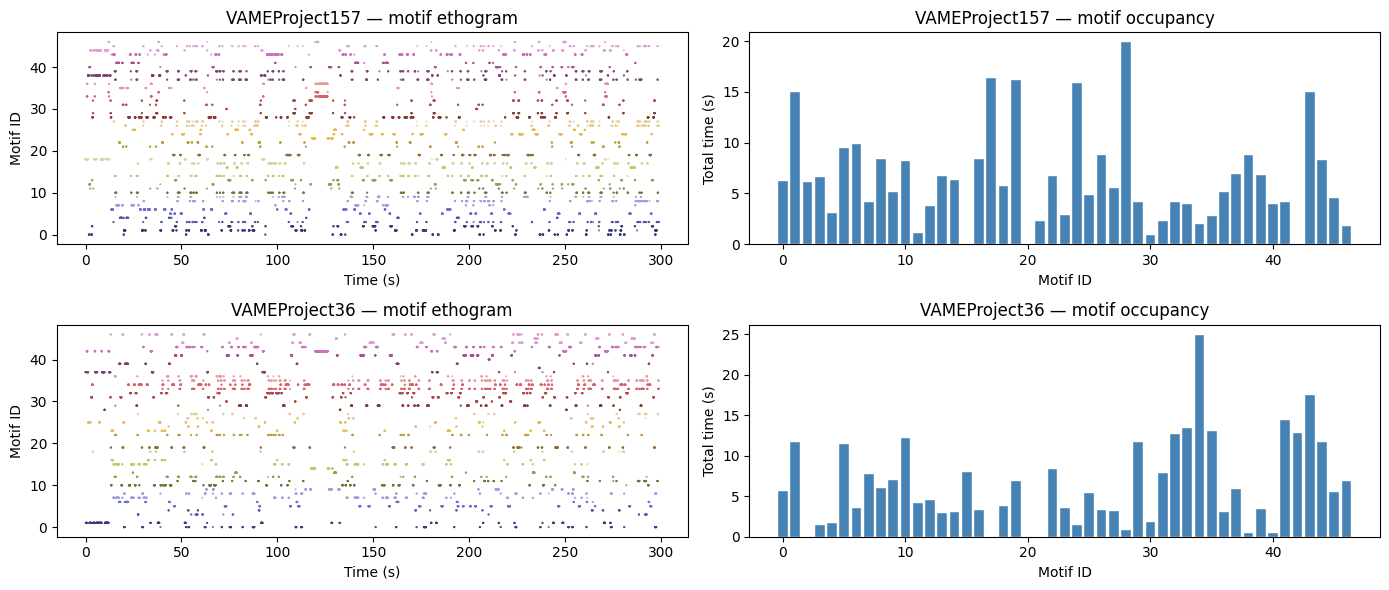

In [54]:
vame_projects = {k: v for k, v in behavior1.data_interfaces.items() if type(v).__name__ == "VAMEProject"}

for key, project in vame_projects.items():
    ms = project.motif_series
    labels = np.array(ms.data[:])
    print(f"{key}:")
    print(f"  MotifSeries name:       {ms.name}")
    print(f"  Shape:                  {labels.shape}  ({labels.shape[0] / ms.rate:.1f} s at {ms.rate} Hz)")
    print(f"  Unique motifs:          {len(np.unique(labels))}  (labels {labels.min()}–{labels.max()})")
    print(f"  Pose estimation linked: {project.pose_estimation is not None}")
    print()

fig, axes = plt.subplots(len(vame_projects), 2, figsize=(14, 3 * len(vame_projects)))

for row_axes, (key, project) in zip(axes, vame_projects.items()):
    ms = project.motif_series
    labels = np.array(ms.data[:])
    time_s = np.arange(len(labels)) / ms.rate

    ax_eth, ax_bar = row_axes
    ax_eth.scatter(time_s, labels, s=0.3, c=labels, cmap="tab20b", alpha=0.7)
    ax_eth.set_xlabel("Time (s)")
    ax_eth.set_ylabel("Motif ID")
    ax_eth.set_title(f"{key} — motif ethogram")

    unique, counts = np.unique(labels, return_counts=True)
    ax_bar.bar(unique, counts / ms.rate, color="steelblue", edgecolor="white", linewidth=0.3)
    ax_bar.set_xlabel("Motif ID")
    ax_bar.set_ylabel("Total time (s)")
    ax_bar.set_title(f"{key} — motif occupancy")

plt.tight_layout()
plt.show()

### 1.4 Figure 5D — Motif length and mean velocity distributions

Replication of **Figure 5D** from Mantas et al. (2024).

For each VAME motif we extract every contiguous bout (consecutive frames with the same label)
across all **31 `oft_fp` sessions** — the sub-experiment that has simultaneous fiber photometry,
VAME labels (`VAMEProject157`), and derived kinematics — and compute:

- **Bout duration (s)**: number of consecutive frames divided by 30 Hz
- **Mean speed (cm/s)**: mean `linear_velocity` during the bout

Motifs are **ranked by mean speed** (fastest at top, slowest at bottom), matching the
manuscript's velocity-ordered ridge plot. The color gradient runs from purple (fast/top) to
light blue (slow/bottom), and the ordering places **motif 17 at the top** and **motif 36 at
the bottom**, exactly as in the figure.

In [37]:
# Load all 31 oft_fp sessions and extract motif bouts
import csv
from pathlib import Path
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

NWB_DIR = Path("../../../nwb_output/open_field_test")
DETAILS_PATH = Path("/Volumes/T9/data/Meletis/oft/details.csv")
FPS = 30.0

with open(DETAILS_PATH) as f:
    _details = {r["video"]: r for r in csv.DictReader(f)}


def _video_stem(nwb_path):
    ses = nwb_path.stem.split("_ses-")[1]
    before_T, after_T = ses.split("T", 1)
    return before_T.replace("-", "_", 1) + "T" + after_T.replace("-", "_")


fp_nwb_paths = [
    p
    for p in sorted(NWB_DIR.glob("sub-*/sub-*.nwb"))
    if (r := _details.get(_video_stem(p))) and r["experiment"] == "oft_fp"
]
print(f"Found {len(fp_nwb_paths)} oft_fp sessions")


def _extract_bouts(labels, velocity, fps=30.0):
    """Return dict motif_id -> {durations, mean_speeds} for all contiguous runs."""
    bouts = {}
    n = min(len(labels), len(velocity))
    i = 0
    while i < n:
        cur = labels[i]
        j = i + 1
        while j < n and labels[j] == cur:
            j += 1
        mean_spd = float(np.nanmean(velocity[i:j]))
        if np.isfinite(mean_spd):
            if cur not in bouts:
                bouts[cur] = {"durations": [], "mean_speeds": []}
            bouts[cur]["durations"].append((j - i) / fps)
            bouts[cur]["mean_speeds"].append(mean_spd)
        i = j
    return bouts


all_bouts: dict = {}
for p in fp_nwb_paths:
    io_sess = NWBHDF5IO(str(p), "r")
    nwb_sess = io_sess.read()
    beh_sess = nwb_sess.processing.get("behavior")
    if (
        beh_sess is None
        or "VAMEProject157" not in beh_sess.data_interfaces
        or "Kinematics" not in beh_sess.data_interfaces
    ):
        io_sess.close()
        continue
    labels_arr = np.array(beh_sess["VAMEProject157"].motif_series.data[:])
    kin_ts = beh_sess["Kinematics"].time_series
    vel_key = "linear_velocity" if "linear_velocity" in kin_ts else "speed"
    velocity_arr = kin_ts[vel_key].data[:].copy()
    io_sess.close()
    for m, d in _extract_bouts(labels_arr, velocity_arr).items():
        if m not in all_bouts:
            all_bouts[m] = {"durations": [], "mean_speeds": []}
        all_bouts[m]["durations"].extend(d["durations"])
        all_bouts[m]["mean_speeds"].extend(d["mean_speeds"])

# Rank motifs by mean speed, fastest first
motif_mean_spd = {m: float(np.mean(d["mean_speeds"])) for m, d in all_bouts.items()}
motif_order_fast_first = sorted(motif_mean_spd, key=motif_mean_spd.get, reverse=True)

print(f"Motifs: {len(motif_order_fast_first)}")
print(f"Fastest (top):    motif {motif_order_fast_first[0]}  ({motif_mean_spd[motif_order_fast_first[0]]:.2f} cm/s)")
print(f"Slowest (bottom): motif {motif_order_fast_first[-1]}  ({motif_mean_spd[motif_order_fast_first[-1]]:.2f} cm/s)")


Found 31 oft_fp sessions


/var/folders/vv/cv45rgsd39z2bm7hjhh65xm80000gn/T/ipykernel_36659/2361580647.py:39: RuntimeWarning: Mean of empty slice
  mean_spd = float(np.nanmean(velocity[i:j]))


Motifs: 47
Fastest (top):    motif 17  (9.64 cm/s)
Slowest (bottom): motif 36  (0.11 cm/s)


/var/folders/vv/cv45rgsd39z2bm7hjhh65xm80000gn/T/ipykernel_36659/875211507.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


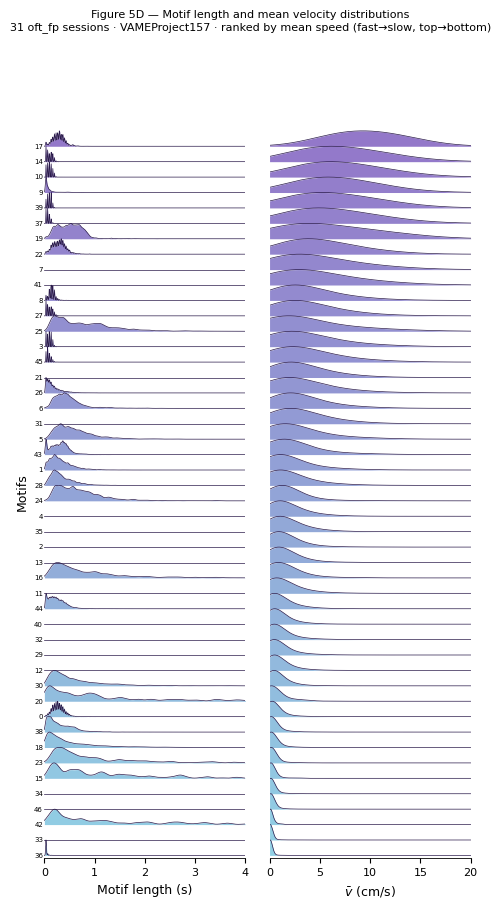

In [38]:
# Figure 5D ridge plots — motif length and mean velocity


def _ridge_plot(ax, values_per_row, row_labels, x_range, bandwidth=None, overlap=0.75, colors=None, x_label=""):
    """Ridge / joy plot — row 0 is drawn at the bottom, row n-1 at the top."""
    n = len(values_per_row)
    x_grid = np.linspace(x_range[0], x_range[1], 500)
    kdes, row_maxes = [], []
    for vals in values_per_row:
        arr = np.asarray(vals)
        arr = arr[(arr >= x_range[0]) & (arr <= x_range[1])]
        if len(arr) < 5 or arr.std() == 0:
            kdes.append(np.zeros_like(x_grid))
            row_maxes.append(1.0)
            continue
        try:
            density = gaussian_kde(arr, bw_method=bandwidth or "scott")(x_grid)
        except Exception:
            kdes.append(np.zeros_like(x_grid))
            row_maxes.append(1.0)
            continue
        kdes.append(density)
        row_maxes.append(max(float(density.max()), 1e-12))

    row_h = overlap
    if colors is None:
        colors = ["#9070C0"] * n
    for i in range(n - 1, -1, -1):  # draw bottom rows first so upper rows paint on top
        y_base = i * row_h
        density = kdes[i] / row_maxes[i] * row_h
        ax.fill_between(x_grid, y_base, y_base + density, color=colors[i], alpha=0.85, linewidth=0, zorder=i + 1)
        ax.plot(x_grid, y_base + density, color="#2A1A4A", linewidth=0.5, zorder=i + 2)

    ax.set_yticks([i * row_h + row_h * 0.05 for i in range(n)])
    ax.set_yticklabels(row_labels, fontsize=5)
    ax.set_xlim(x_range)
    ax.set_ylim(-row_h * 0.15, (n - 1) * row_h + row_h * 1.3)
    ax.set_xlabel(x_label, fontsize=9)
    ax.tick_params(axis="y", length=0, pad=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.tick_params(axis="x", labelsize=8)


# Color gradient: purple (fast/top) → light blue (slow/bottom)
# motif_order_fast_first[0] = fastest = top; reversed gives [slowest...fastest]
n_m = len(motif_order_fast_first)
_vel_cmap = LinearSegmentedColormap.from_list("vel_cmap", ["#7EC8E0", "#8060C0"])
motif_order_bottom_to_top = list(reversed(motif_order_fast_first))  # index 0 = slowest (bottom)
colors_ridges = [_vel_cmap(i / max(n_m - 1, 1)) for i in range(n_m)]

dur_list = [all_bouts[m]["durations"] for m in motif_order_bottom_to_top]
spd_list = [all_bouts[m]["mean_speeds"] for m in motif_order_bottom_to_top]
labels_list_5d = [str(m) for m in motif_order_bottom_to_top]

fig5d, axes5d = plt.subplots(1, 2, figsize=(5.5, 9.5), sharey=True, gridspec_kw={"wspace": 0.12})

_ridge_plot(
    axes5d[0], dur_list, labels_list_5d,
    x_range=(0, 4), bandwidth=0.08,
    colors=colors_ridges, x_label="Motif length (s)",
)
_ridge_plot(
    axes5d[1], spd_list, labels_list_5d,
    x_range=(0, 20), bandwidth=0.8,
    colors=colors_ridges, x_label=r"$\bar{v}$ (cm/s)",
)

axes5d[0].set_ylabel("Motifs", fontsize=9, labelpad=4)
fig5d.suptitle(
    "Figure 5D — Motif length and mean velocity distributions\n"
    "31 oft_fp sessions · VAMEProject157 · ranked by mean speed (fast→slow, top→bottom)",
    fontsize=8,
    y=1.003,
)
plt.tight_layout()
plt.show()


## Example 2: Fiber photometry + kinematics session

This session (sub-687662, Anxa1-Flp, `oft_fp` sub-experiment) has simultaneous fiber photometry
recording (jGCaMP8m sensor, fiber implanted in the dorsal caudoputamen) alongside pose estimation
and derived kinematics.

In [55]:
nwb_path_fp = "../../../nwb_output/open_field_test/sub-687662/sub-687662_ses-tmaze-2023-05-05T13-09-53.nwb"

io2 = NWBHDF5IO(nwb_path_fp, mode="r")
nwbfile2 = io2.read()

print(f"Session ID:    {nwbfile2.session_id}")
print(f"Session start: {nwbfile2.session_start_time}")
print(f"Subject ID:    {nwbfile2.subject.subject_id}")
print(f"Genotype:      {nwbfile2.subject.genotype}")
print(f"Sex:           {nwbfile2.subject.sex}")
print(f"Institution:   {nwbfile2.institution}")
print(f"Lab:           {nwbfile2.lab}")

Session ID:    tmaze-2023-05-05T13-09-53
Session start: 2023-05-05 13:09:53+02:00
Subject ID:    687662
Genotype:      anxa1-flp
Sex:           U
Institution:   Karolinska Institutet
Lab:           Meletis


### 2.1 Fiber photometry

Fiber photometry recorded dopamine/calcium dynamics in `oft_fp` sessions (31 of 161).
The signal is motion-corrected dF/F (470 nm signal minus 405 nm isosbestic reference)
sampled at ~60 Hz.

| Group | Location | Indicator | Fiber insertion |
|-------|----------|-----------|-----------------|
| `dLight_dStr` | Dorsal caudoputamen | dLight1.3b | dCP (AP +0.74, ML ±1.5, DV −2.2) |
| `dLight_vStr` | Central caudoputamen | dLight1.3b | cCP (AP +0.38, ML +2.0, DV −2.9) |
| `fp_dat` / `dat-cre` | Dorsal caudoputamen | jGCaMP8m | dCP |
| `fp_anxa1` / `anxa1-flp` | Dorsal caudoputamen | jGCaMP8m | dCP |

**Note:** Timestamps start at ~5–8 s due to system warm-up. Video and FP clocks are
synchronized by Bonsai at session start.

In [ ]:
fp = nwbfile2.processing["ophys"]["DfOverFFiberPhotometryResponseSeries"]
signal = fp.data[:]
timestamps = fp.timestamps[:]

print(f"Description: {fp.description}")
print(f"Unit: {fp.unit}")
print(f"Data shape: {signal.shape}")
print(f"Time range: {timestamps[0]:.2f} – {timestamps[-1]:.2f} s")
print(f"Sampling rate: ~{1 / np.median(np.diff(timestamps)):.1f} Hz")

fp_meta = nwbfile2.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table
print(f"\nRecording location:    {fp_table['location'][0]}")
print(f"Excitation wavelength: {fp_table['excitation_wavelength_in_nm'][0]} nm")
print(f"Emission wavelength:   {fp_table['emission_wavelength_in_nm'][0]} nm")

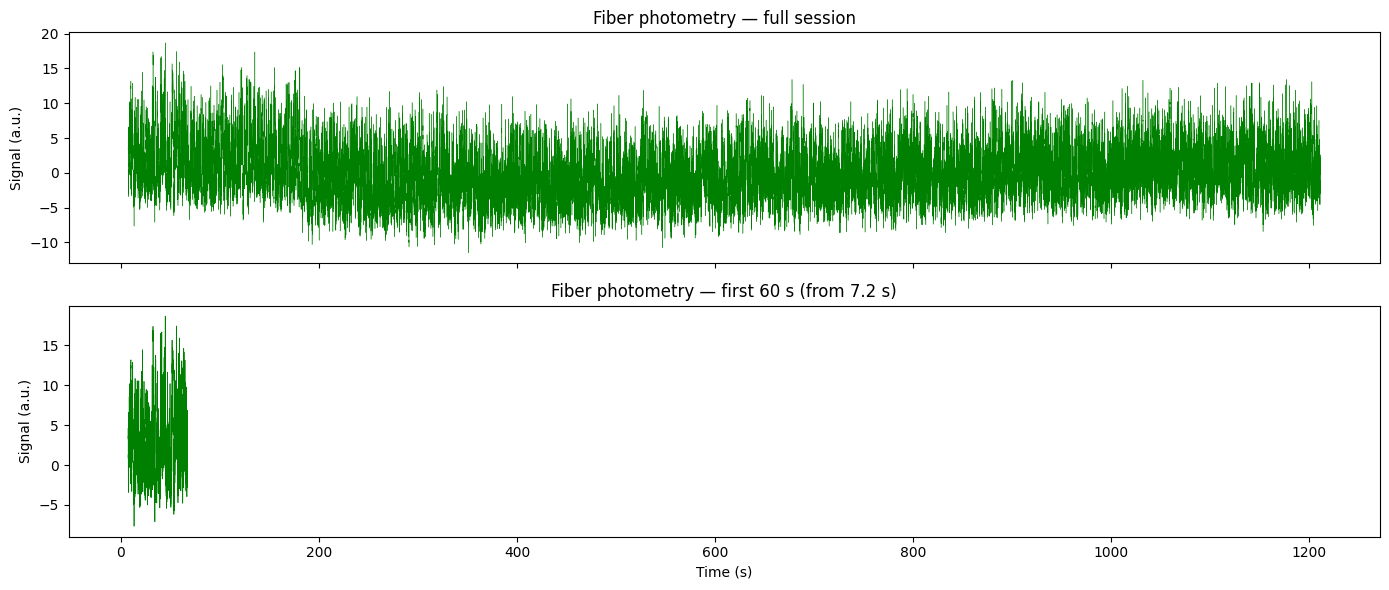

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(timestamps, signal, linewidth=0.3, color="green")
axes[0].set_ylabel("Signal (a.u.)")
axes[0].set_title("Fiber photometry — full session")

t_start, t_end = timestamps[0], min(timestamps[0] + 60, timestamps[-1])
mask = (timestamps >= t_start) & (timestamps <= t_end)
axes[1].plot(timestamps[mask], signal[mask], linewidth=0.5, color="green")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Signal (a.u.)")
axes[1].set_title(f"Fiber photometry — first 60 s (from {t_start:.1f} s)")

plt.tight_layout()
plt.show()

### 2.2 Kinematics

Derived kinematics computed from the pose estimation data, stored in
`processing/behavior/Kinematics` as a `BehavioralTimeSeries` container at 30 Hz.

| Time series | Unit | Description |
|-------------|------|-------------|
| `linear_velocity` | m/s | Movement speed of the body center |
| `linear_acceleration` | m/s² | Movement acceleration of the body center |
| `angular_velocity` | rad/s | Angular speed of body orientation |
| `distance_moved` | m | Distance moved by the body center per frame |
| `angular_distance` | rad | Angular distance of body orientation change per frame |
| `linear_velocity_snout` | m/s | Movement speed of the snout |
| `distance_moved_snout` | m | Distance moved by the snout per frame |

In [42]:
behavior2 = nwbfile2.processing["behavior"]
kinematics = behavior2["Kinematics"]

print("Available kinematics time series:")
for name, ts in kinematics.time_series.items():
    data = ts.data[:]
    print(f"  {name:25s}  shape={str(data.shape):12s}  unit={ts.unit:12s}  range=[{data.min():.2f}, {data.max():.2f}]")

Available kinematics time series:
  acceleration               shape=(36466,)      unit=pixels/s^2    range=[-242.23, 256.27]
  angular_distance           shape=(36466,)      unit=rad           range=[0.00, 0.09]
  angular_speed              shape=(36466,)      unit=rad/s         range=[0.00, 2.64]
  distance_moved             shape=(36466,)      unit=pixels        range=[0.00, 0.50]
  distance_moved_snout       shape=(36466,)      unit=pixels        range=[0.00, 0.54]
  speed                      shape=(36466,)      unit=pixels/s      range=[0.00, 15.08]
  speed_snout                shape=(36466,)      unit=pixels/s      range=[0.00, 16.09]


In [ ]:
speed = kinematics.time_series["linear_velocity"]
speed_data = speed.data[:]
speed_time = np.arange(len(speed_data)) / speed.rate

angular_speed = kinematics.time_series["angular_velocity"]
angular_data = angular_speed.data[:]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(speed_time, speed_data, linewidth=0.3, color="steelblue")
axes[0].set_ylabel(f"Speed ({speed.unit})")
axes[0].set_title("Body center linear velocity (Example 2)")

axes[1].plot(speed_time, angular_data, linewidth=0.3, color="darkorange")
axes[1].set_ylabel(f"Angular velocity ({angular_speed.unit})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Angular velocity")

plt.tight_layout()
plt.show()

### 2.3 Combined dF/F and velocity trace

Both signals share the same time reference (synchronized by Bonsai at session start).
The dF/F signal is globally z-scored for display; velocity is plotted in the native unit
stored in the NWB file. FP timestamps begin at ~7 s due to system warm-up.

The zoomed panel (bottom row) shows a 60-second representative window to make the
sub-second co-modulation visible.

/var/folders/vv/cv45rgsd39z2bm7hjhh65xm80000gn/T/ipykernel_36659/233760750.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


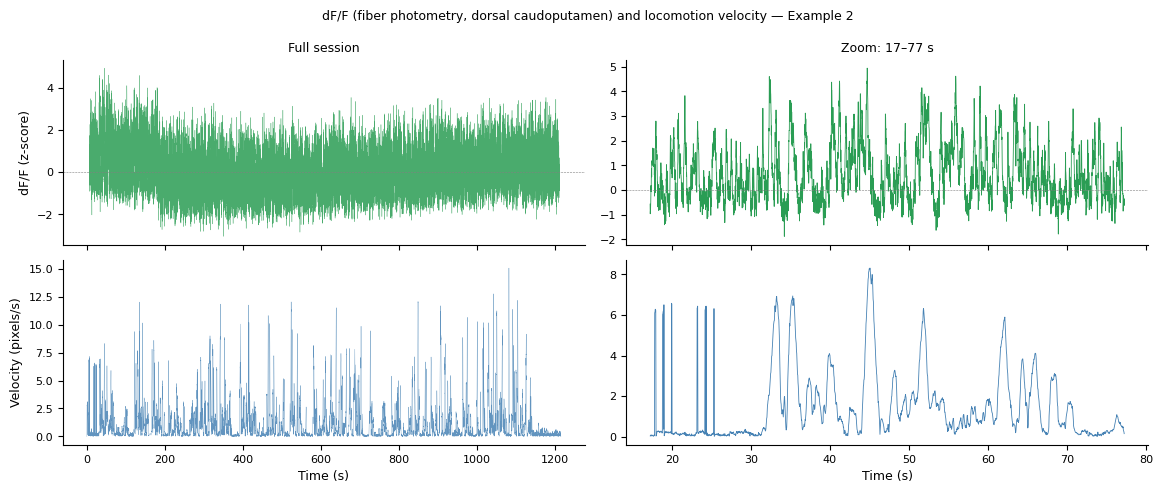

In [44]:
# Z-score dF/F for display
signal_z = (signal - signal.mean()) / signal.std()

# Choose a 60-second zoom window starting where FP is stable
_t0_zoom = float(timestamps[0]) + 10.0
_t1_zoom = _t0_zoom + 60.0

fig_comb, axes_comb = plt.subplots(
    2, 2,
    figsize=(14, 5),
    sharex="col",
    gridspec_kw={"wspace": 0.08, "hspace": 0.08},
)

# ---------- full session (left column) ----------
axes_comb[0, 0].plot(timestamps, signal_z, linewidth=0.25, color="#2a9d54", alpha=0.85)
axes_comb[0, 0].set_ylabel("dF/F (z-score)", fontsize=9)
axes_comb[0, 0].set_title("Full session", fontsize=9)
axes_comb[0, 0].axhline(0, color="gray", linewidth=0.4, linestyle="--")

axes_comb[1, 0].plot(speed_time, speed_data, linewidth=0.25, color="steelblue", alpha=0.85)
axes_comb[1, 0].set_ylabel(f"Velocity ({speed.unit})", fontsize=9)
axes_comb[1, 0].set_xlabel("Time (s)", fontsize=9)

# ---------- 60-second zoom (right column) ----------
_fp_mask = (timestamps >= _t0_zoom) & (timestamps <= _t1_zoom)
_vel_mask = (speed_time >= _t0_zoom) & (speed_time <= _t1_zoom)

axes_comb[0, 1].plot(timestamps[_fp_mask], signal_z[_fp_mask], linewidth=0.6, color="#2a9d54")
axes_comb[0, 1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes_comb[0, 1].set_title(f"Zoom: {_t0_zoom:.0f}–{_t1_zoom:.0f} s", fontsize=9)

axes_comb[1, 1].plot(speed_time[_vel_mask], speed_data[_vel_mask], linewidth=0.6, color="steelblue")
axes_comb[1, 1].set_xlabel("Time (s)", fontsize=9)

for ax in axes_comb.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

fig_comb.suptitle(
    "dF/F (fiber photometry, dorsal caudoputamen) and locomotion velocity — Example 2",
    fontsize=9,
)
plt.tight_layout()
plt.show()


## NWB file structure overview

Summary of all containers in both example files.

In [45]:
for label, nwbfile in [("Example 1 — VAME", nwbfile1), ("Example 2 — FP + Kinematics", nwbfile2)]:
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print("Acquisition:")
    for name, obj in nwbfile.acquisition.items():
        print(f"  {name}: {type(obj).__name__}")
    print("\nProcessing:")
    for mod_name, module in nwbfile.processing.items():
        print(f"  {mod_name}/")
        for name, obj in module.data_interfaces.items():
            print(f"    {name}: {type(obj).__name__}")
    print("\nDevices:")
    for name in nwbfile.devices:
        print(f"  {name}")
    if nwbfile.lab_meta_data:
        print("\nLab metadata:")
        for name in nwbfile.lab_meta_data:
            print(f"  {name}")


  Example 1 — VAME
Acquisition:
  Video oft_2023-05-16T15_31_06: ImageSeries

Processing:
  behavior/
    PoseEstimationDeepLabCut: PoseEstimation
    Skeletons: Skeletons
    VAMEProject157: VAMEProject
    VAMEProject36: VAMEProject

Devices:
  CameraPoseEstimationDeepLabCut
  None Camera Device

  Example 2 — FP + Kinematics
Acquisition:
  FiberPhotometryResponseSeries: FiberPhotometryResponseSeries
  Video tmaze_2023-05-05T13_09_53: ImageSeries

Processing:
  behavior/
    Kinematics: BehavioralTimeSeries
    PoseEstimationDeepLabCut: PoseEstimation
    Skeletons: Skeletons

Devices:
  CameraPoseEstimationDeepLabCut
  None Camera Device
  excitation_source
  optical_fiber
  photodetector

Lab metadata:
  fiber_photometry


In [46]:
io1.close()
io2.close()